# Test on ERA5

In [50]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [51]:
import os
from datetime import datetime
from pyproj import CRS

In [52]:
from etdataset.dem import get_elevation_from_tile
import etdataset.era5 as era5

## Init

In [53]:
if os.environ["ETDATASET_TEST_DATA_PATH"] is None:
    raise Exception("Variable EVASPA_TEST_DATA_PATH must be set")

In [54]:
data_path = os.environ["ETDATASET_TEST_DATA_PATH"]

## Read ERA5 data

In [91]:
era5_path = os.path.join(data_path, "era5", "download_era5_2023-10-10_44.35_0.40_43.14_1.99.nc")

In [92]:
data = era5.ERA5Data(era5_path)

In [93]:
data.get_available_dates()

['2023-10-10 00:00:00',
 '2023-10-10 01:00:00',
 '2023-10-10 02:00:00',
 '2023-10-10 03:00:00',
 '2023-10-10 04:00:00',
 '2023-10-10 05:00:00',
 '2023-10-10 06:00:00',
 '2023-10-10 07:00:00',
 '2023-10-10 08:00:00',
 '2023-10-10 09:00:00',
 '2023-10-10 10:00:00',
 '2023-10-10 11:00:00',
 '2023-10-10 12:00:00',
 '2023-10-10 13:00:00',
 '2023-10-10 14:00:00',
 '2023-10-10 15:00:00',
 '2023-10-10 16:00:00',
 '2023-10-10 17:00:00',
 '2023-10-10 18:00:00',
 '2023-10-10 19:00:00',
 '2023-10-10 20:00:00',
 '2023-10-10 21:00:00',
 '2023-10-10 22:00:00',
 '2023-10-10 23:00:00']

In [94]:
data.get_available_variables()

['u10',
 'v10',
 'd2m',
 't2m',
 'ssrdc',
 'ssrd',
 'strdc',
 'strd',
 'tco3',
 'tcw',
 'tp',
 'tcwv',
 'z']

In [96]:
data.transform

Affine(0.250166, 0.0, 0.269917,
       0.0, -0.250166, 44.264083)

In [59]:
arr, t, x, y , crs = data.read_as_numpy([era5.ERA5Var("t2m")],['2023-10-10'])

In [100]:
toto = data.read(variables=[era5.ERA5Var.TEMPERATURE])

In [60]:
xrds = data.read([era5.ERA5Var.TEMPERATURE,era5.ERA5Var.DEWPOINT_TEMPERATURE,era5.ERA5Var.SURFACE_SOLAR_RADIATION_DOWNWARD,era5.ERA5Var.GEOPOTENTIAL],['2023-10-10'])
xrds

<xarray.Dataset> Size: 14kB
Dimensions:  (t: 24, y: 5, x: 7)
Coordinates:
  * t        (t) datetime64[ns] 192B 2023-10-10 ... 2023-10-10T23:00:00
  * x        (x) float64 56B 0.395 0.6452 0.8953 1.145 1.396 1.646 1.896
  * y        (y) float64 40B 44.14 43.89 43.64 43.39 43.14
Data variables:
    t2m      (t, y, x) float32 3kB 288.2 288.2 288.1 288.0 ... 287.8 287.6 287.1
    d2m      (t, y, x) float32 3kB 284.4 283.8 283.6 283.1 ... 283.0 282.1 282.1
    ssrd     (t, y, x) float32 3kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    z        (t, y, x) float32 3kB 1.138e+03 1.254e+03 ... 4.624e+03 4.94e+03
Attributes:
    crs:         EPSG:4326
    transform:   | 0.25, 0.00, 0.27|\n| 0.00,-0.25, 44.26|\n| 0.00, 0.00, 1.00|
    bounds:      BoundingBox(left=0.269917, bottom=43.012917, right=2.021083,...
    resolution:  {'x': 0.250166, 'y': 0.250166}

In [101]:
t2m = data.get(era5.ERA5Var.TEMPERATURE,datetime(2023,10,10,12,30,00))
t2m

<xarray.DataArray 't2m' (y: 5, x: 7)> Size: 280B
array([[302.78948975, 303.04681396, 302.97766113, 302.91107178,
        302.7321167 , 302.20196533, 300.96636963],
       [302.37982178, 302.65393066, 302.88818359, 302.84686279,
        302.9284668 , 302.5201416 , 302.17138672],
       [301.53088379, 301.8236084 , 302.08605957, 302.45843506,
        302.56536865, 302.60626221, 302.25415039],
       [300.10931396, 300.39520264, 301.15570068, 301.59472656,
        302.05145264, 302.11383057, 302.10614014],
       [297.48553467, 298.15509033, 298.98046875, 299.60144043,
        300.0670166 , 300.56158447, 300.60449219]])
Coordinates:
  * x        (x) float64 56B 0.395 0.6452 0.8953 1.145 1.396 1.646 1.896
  * y        (y) float64 40B 44.14 43.89 43.64 43.39 43.14
    t        datetime64[ns] 8B 2023-10-10T12:30:00
Attributes:
    crs:         EPSG:4326
    transform:   | 0.25, 0.00, 0.27|\n| 0.00,-0.25, 44.26|\n| 0.00, 0.00, 1.00|
    bounds:      BoundingBox(left=0.269917, bottom=43.012917, right=2.021083,...
    resolution:  {'x': 0.250166, 'y': 0.250166}

In [62]:
zref = data.get(era5.ERA5Var.HEIGHT, datetime(2023, 10, 10, 12, 30, 00))

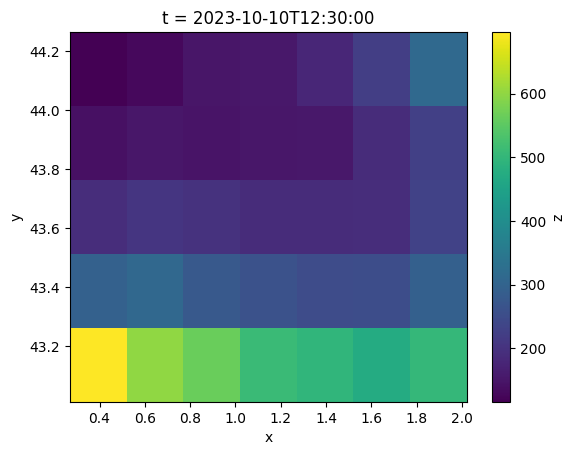

In [63]:
zref.plot()

## Interpolation method

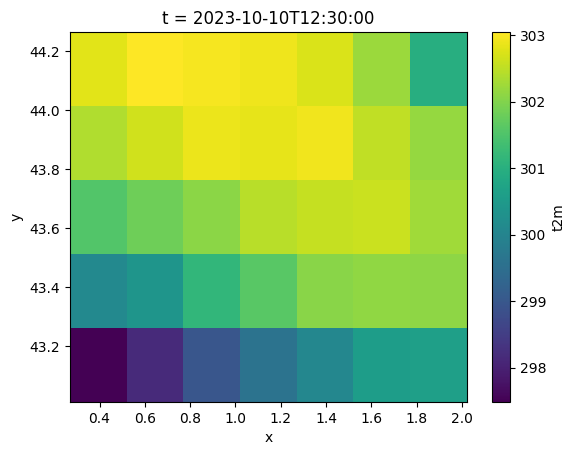

In [65]:
t2m.plot()

{'crs': 'EPSG:4326', 'transform': Affine(0.250166, 0.0, np.float64(0.269917),
       0.0, -0.250166, np.float64(44.264083)), 'bounds': BoundingBox(left=0.269917, bottom=43.012917, right=2.021083, top=44.264083), 'resolution': {'x': 0.250166, 'y': 0.250166}}


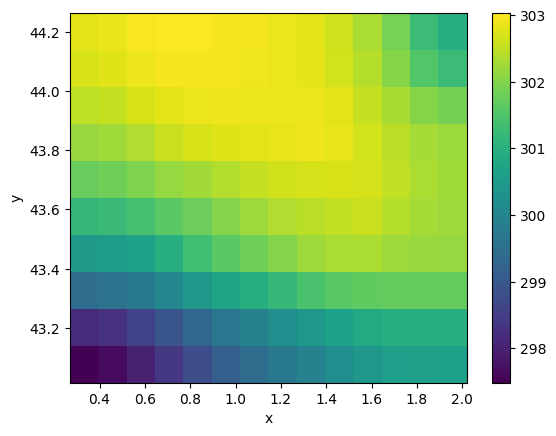

In [66]:
era5.interpolate(t2m,resolution=0.125).plot()

## Interpolation of temperature

In [67]:
dem = get_elevation_from_tile("31TCJ")

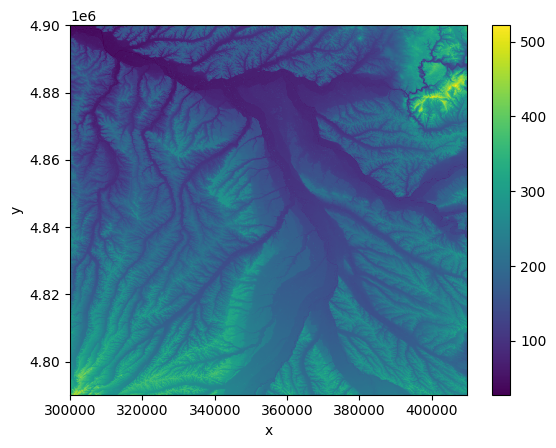

In [68]:
dem.plot()

In [75]:
dem_temp = era5.interpolate_temperature(t2m,zref,dem,lapse_rate=0.0065)

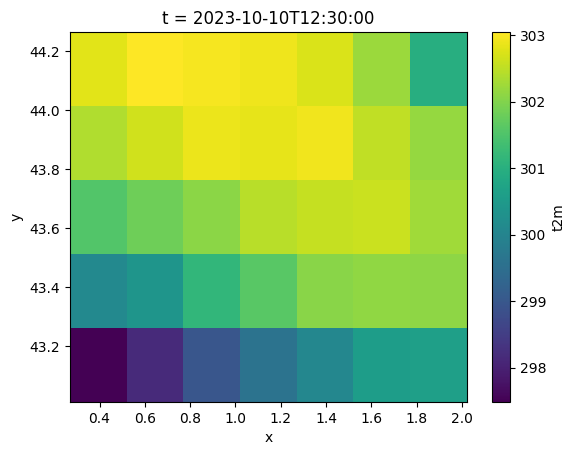

In [77]:
t2m.plot()

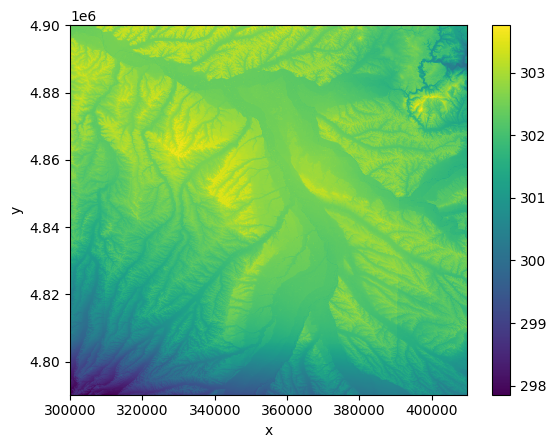

In [76]:
dem_temp.plot()

# Download data

In [83]:
from sensorsio import mgrs

In [84]:
bbox = mgrs.get_bbox_mgrs_tile("31TCJ")

In [52]:
era5.download_era5(datetime(2023,10,10),bbox,CRS(4326))

2024-10-11 11:40:49,013 INFO [2024-09-28T00:00:00] **Welcome to the New Climate Data Store (CDS)!** This new system is in its early days of full operations and still undergoing enhancements and fine tuning. Some disruptions are to be expected. Your 
[feedback](https://jira.ecmwf.int/plugins/servlet/desk/portal/1/create/202) is key to improve the user experience on the new CDS for the benefit of everyone. Thank you.
2024-10-11 11:40:49,014 WARNING [2024-09-26T00:00:00] Should you have not yet migrated from the old CDS system to the new CDS, please check our [informative page](https://confluence.ecmwf.int/x/uINmFw) for guidance.
2024-10-11 11:40:49,015 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2024-10-11 11:40:49,016 INFO [2024-09-16T00:00:00] Remember that you need to have an ECMWF account to use the new CDS. **Your old CDS credentials will not work in new CDS!**
2024-10-11 11:40:49,016 WARNING [2024-06-16T

36009c2794e893ac331cdea8448ce00b.nc:   0%|          | 0.00/152k [00:00<?, ?B/s]

In [85]:
era5.download_era5land(datetime(2023,10,10),bbox,CRS(4326))

2024-10-15 15:29:42,477 INFO [2024-09-28T00:00:00] **Welcome to the New Climate Data Store (CDS)!** This new system is in its early days of full operations and still undergoing enhancements and fine tuning. Some disruptions are to be expected. Your 
[feedback](https://jira.ecmwf.int/plugins/servlet/desk/portal/1/create/202) is key to improve the user experience on the new CDS for the benefit of everyone. Thank you.
24-10-15 15:29:42 :: INFO :: [2024-09-28T00:00:00] **Welcome to the New Climate Data Store (CDS)!** This new system is in its early days of full operations and still undergoing enhancements and fine tuning. Some disruptions are to be expected. Your 
[feedback](https://jira.ecmwf.int/plugins/servlet/desk/portal/1/create/202) is key to improve the user experience on the new CDS for the benefit of everyone. Thank you.
2024-10-15 15:29:42,478 WARNING [2024-09-26T00:00:00] Should you have not yet migrated from the old CDS system to the new CDS, please check our [informative page]

815d0466709c165b6aa77650cf82e4df.nc:   0%|          | 0.00/145k [00:00<?, ?B/s]